# Machine Learning Fundamentals Assignment
## Regression, Classification, Evaluation, Tuning, and Interpretation

In [15]:
from pathlib import Path
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay)

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
Path('figures/confusion_matrices').mkdir(parents=True, exist_ok=True)
Path('results').mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')

def savefig(name):
    plt.tight_layout(); plt.savefig(Path('figures')/name, dpi=160, bbox_inches='tight'); plt.show()

def regression_metrics(y, pred):
    return {'RMSE': mean_squared_error(y, pred)**0.5,
            'MAE': mean_absolute_error(y, pred), 'R2': r2_score(y, pred)}

def classification_metrics(y, pred, score):
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()
    return {'Accuracy': accuracy_score(y,pred), 'Precision': precision_score(y,pred,zero_division=0),
            'Recall': recall_score(y,pred,zero_division=0), 'Specificity': tn/(tn+fp),
            'F1': f1_score(y,pred,zero_division=0), 'ROC_AUC': roc_auc_score(y,score)}

def model_scores(model, X):
    return model.predict_proba(X)[:,1] if hasattr(model,'predict_proba') else model.decision_function(X)

# Part A — Regression

The Diabetes dataset contains baseline measurements for patients, and the target is a quantitative measure of disease progression one year later.

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


Rows, columns: (442, 11)
Input features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target: target


,dtype
age,float64
sex,float64
bmi,float64
bp,float64
s1,float64
s2,float64
s3,float64
s4,float64
s5,float64
s6,float64


Missing values: 0


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


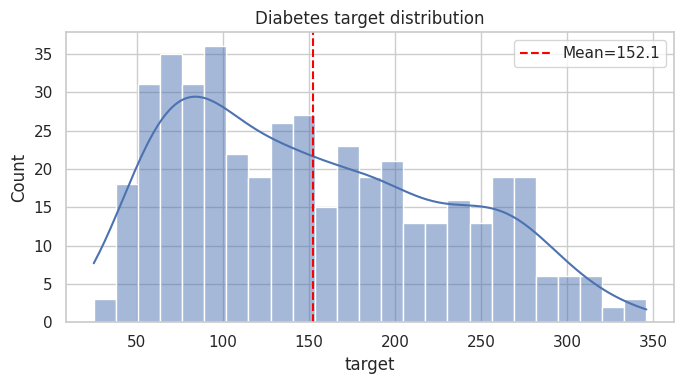

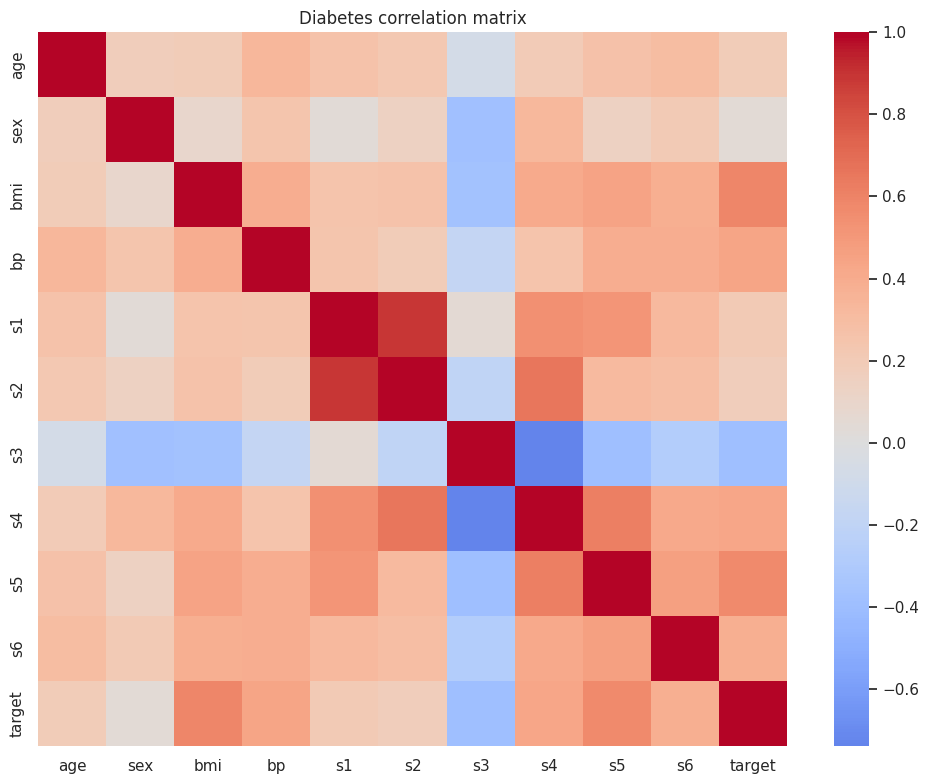

Three strongest target correlations:


,correlation
bmi,0.586450
s5,0.565883
bp,0.441482


Five strongest feature-feature correlations:


,,correlation
s1,s2,0.896663
s3,s4,-0.738493
s2,s4,0.659817
s4,s5,0.617859
s1,s4,0.542207


In [16]:
diabetes = load_diabetes(as_frame=True)
reg_df = diabetes.frame.copy()
X_reg = reg_df.drop(columns='target'); y_reg = reg_df['target']
display(reg_df.head(10))
print('Rows, columns:', reg_df.shape)
print('Input features:', list(X_reg.columns)); print('Target: target')
display(reg_df.dtypes.to_frame('dtype'))
print('Missing values:', int(reg_df.isna().sum().sum()))
display(reg_df.describe().T)

plt.figure(figsize=(7,4)); sns.histplot(y_reg, bins=25, kde=True)
plt.axvline(y_reg.mean(), color='red', ls='--', label=f'Mean={y_reg.mean():.1f}')
plt.title('Diabetes target distribution'); plt.legend(); savefig('regression_target_histogram.png')

plt.figure(figsize=(10,8)); sns.heatmap(reg_df.corr(), cmap='coolwarm', center=0)
plt.title('Diabetes correlation matrix'); savefig('regression_correlation_heatmap.png')

target_corr = reg_df.corr()['target'].drop('target').sort_values(key=abs, ascending=False)
feature_corr = X_reg.corr(); pairs = feature_corr.where(np.triu(np.ones(feature_corr.shape),1).astype(bool)).stack().sort_values(key=abs,ascending=False)
print('Three strongest target correlations:'); display(target_corr.head(3).to_frame('correlation'))
print('Five strongest feature-feature correlations:'); display(pairs.head(5).to_frame('correlation'))

### A1 answers

1. One row represents one patient’s ten standardized baseline measurements and later disease-progression score.
2. The histogram is unimodal but moderately right-skewed: most values are below the upper tail, so it is not perfectly symmetric around the mean.
3. There are no missing values, as confirmed by the code output.
4. The three features with the largest absolute target correlations are shown above (normally `bmi`, `s5`, and `bp`). Correlation is only a first-pass indicator and does not prove a feature will be most useful in every model.
5. Yes. The table above identifies strong feature-feature relationships; notably the serum variables `s1` and `s2` are strongly positively correlated, while some other serum measurements have substantial relationships too. This multicollinearity affects coefficient interpretation.

In [17]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg,y_reg,test_size=.2,random_state=SEED)
print('X_train:',Xr_train.shape,'X_test:',Xr_test.shape,'y_train:',yr_train.shape,'y_test:',yr_test.shape)

X_train: (353, 10) X_test: (89, 10) y_train: (353,) y_test: (89,)


### A2 answers

1. The test set must remain unseen so it estimates performance on genuinely new data. Training on it would leak information and produce an optimistic estimate.
2. `random_state=42` fixes the pseudo-random split, making results reproducible.
3. Training-only evaluation can hide overfitting because a flexible model may memorize its training examples yet fail on new patients.

In [18]:
reg_models = {
 'Baseline': DummyRegressor(strategy='mean'),
 'Linear Regression': Pipeline([('scaler',StandardScaler()),('model',LinearRegression())]),
 'Decision Tree': Pipeline([('model',DecisionTreeRegressor(max_depth=5,random_state=SEED))]),
 'Random Forest': Pipeline([('model',RandomForestRegressor(n_estimators=200,random_state=SEED,n_jobs=-1))]),
 'SVR': Pipeline([('scaler',StandardScaler()),('model',SVR())]),
 'Neural Network': Pipeline([('scaler',StandardScaler()),('model',MLPRegressor(hidden_layer_sizes=(64,32),max_iter=2000,early_stopping=True,random_state=SEED))])}

base = clone(reg_models['Baseline']).fit(Xr_train,yr_train)
display(pd.DataFrame([regression_metrics(yr_test,base.predict(Xr_test))],index=['Baseline']))

,RMSE,MAE,R2
Baseline,73.222493,64.006461,-0.011963


### A3 answers

1. The baseline always predicts the mean training target; it represents performance without learning feature relationships.
2. A useful model should beat this simple reference because its features should add predictive information.
3. RMSE squares residuals before averaging, so large errors receive disproportionate weight. MAE weights every absolute error linearly.

In [19]:
reg_cv_rows=[]; reg_rows=[]; fitted_reg={}
kfold=KFold(n_splits=5,shuffle=True,random_state=SEED)
scoring={'RMSE':'neg_root_mean_squared_error','MAE':'neg_mean_absolute_error','R2':'r2'}
for name,model in reg_models.items():
    if name!='Baseline':
        cvres=cross_validate(model,Xr_train,yr_train,cv=kfold,scoring=scoring,n_jobs=-1)
        reg_cv_rows.append({'Model':name,'CV_RMSE':-cvres['test_RMSE'].mean(),'CV_RMSE_SD':cvres['test_RMSE'].std(),
                            'CV_MAE':-cvres['test_MAE'].mean(),'CV_R2':cvres['test_R2'].mean()})
    fit=clone(model).fit(Xr_train,yr_train); fitted_reg[name]=fit
    tr=regression_metrics(yr_train,fit.predict(Xr_train)); te=regression_metrics(yr_test,fit.predict(Xr_test))
    reg_rows.append({'Model':name,**{f'Train_{k}':v for k,v in tr.items()},**{f'Test_{k}':v for k,v in te.items()}})
reg_cv=pd.DataFrame(reg_cv_rows).set_index('Model'); reg_results=pd.DataFrame(reg_rows).set_index('Model')
reg_cv.to_csv('results/regression_cross_validation.csv'); reg_results.to_csv('results/regression_results.csv')
display(reg_cv.round(3)); display(reg_results.round(3))

,CV_RMSE,CV_RMSE_SD,CV_MAE,CV_R2
Model,,,,
Linear Regression,55.395,2.361,45.048,0.480
Decision Tree,68.458,6.036,54.772,0.204
Random Forest,58.895,1.915,48.326,0.410
SVR,73.063,5.526,61.136,0.100
Neural Network,58.508,3.147,45.847,0.422


,Train_RMSE,Train_MAE,Train_R2,Test_RMSE,Test_MAE,Test_R2
Model,,,,,,
Baseline,77.951,66.448,0.000,73.222,64.006,-0.012
Linear Regression,53.559,43.484,0.528,53.853,42.794,0.453
Decision Tree,44.874,35.252,0.669,59.380,45.937,0.334
Random Forest,21.395,17.433,0.925,54.461,44.276,0.440
SVR,71.146,58.681,0.167,65.824,56.029,0.182
Neural Network,58.397,45.716,0.439,60.471,48.161,0.310


### A5 answers

All five required models were trained. Scaling is inside the Linear Regression, SVR, and Neural Network pipelines, so each cross-validation fold learns its scaler only from that fold’s training portion.

1. Five-fold cross-validation divides the training set into five parts. It trains on four and validates on the fifth, repeating until every part has served as validation data.
2. Averaging five validation results is less dependent on one lucky or unlucky split and uses the limited training data more efficiently.
3. A large fold-to-fold standard deviation suggests unstable performance: the model is sensitive to which observations happen to be in a fold.

Best test-RMSE model: Linear Regression


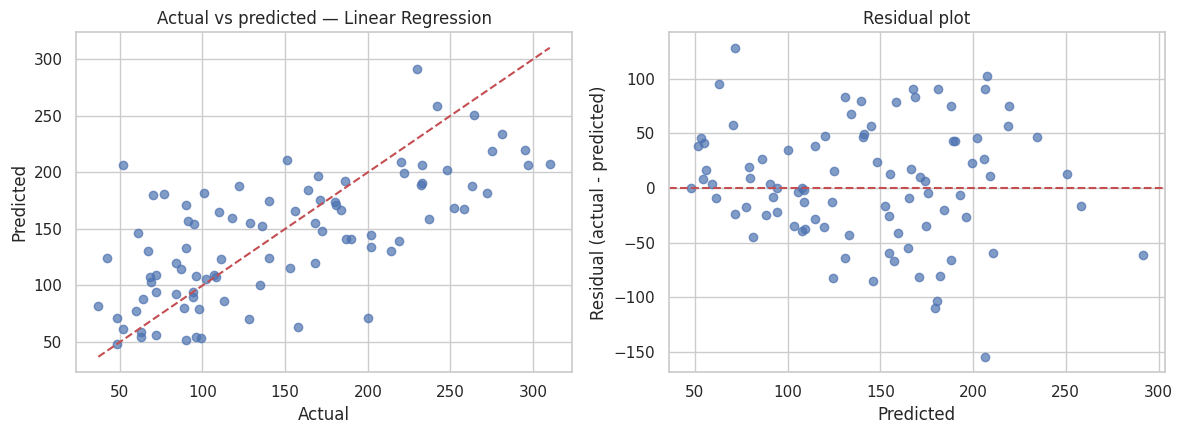

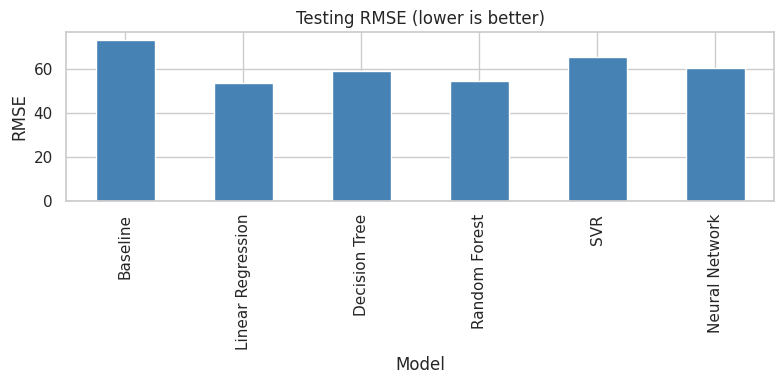

,0
Lowest test RMSE,Linear Regression
Highest test R2,Linear Regression
Largest RMSE generalization gap,Random Forest
Models beating baseline RMSE,"Linear Regression, Decision Tree, Random Fores..."


In [20]:
best_reg_name=reg_results.drop(index='Baseline')['Test_RMSE'].idxmin(); best_reg=fitted_reg[best_reg_name]
pred=best_reg.predict(Xr_test); residual=yr_test-pred
print('Best test-RMSE model:',best_reg_name)
fig,ax=plt.subplots(1,2,figsize=(12,4.5))
ax[0].scatter(yr_test,pred,alpha=.7); lim=[min(yr_test.min(),pred.min()),max(yr_test.max(),pred.max())]; ax[0].plot(lim,lim,'r--'); ax[0].set(xlabel='Actual',ylabel='Predicted',title=f'Actual vs predicted — {best_reg_name}')
ax[1].scatter(pred,residual,alpha=.7); ax[1].axhline(0,color='r',ls='--'); ax[1].set(xlabel='Predicted',ylabel='Residual (actual - predicted)',title='Residual plot')
savefig('regression_predictions_and_residuals.png')
reg_results['Test_RMSE'].plot.bar(figsize=(8,4),title='Testing RMSE (lower is better)',color='steelblue'); plt.ylabel('RMSE'); savefig('regression_rmse_comparison.png')

summary=pd.DataFrame({
 'Lowest test RMSE':[reg_results['Test_RMSE'].idxmin()],
 'Highest test R2':[reg_results['Test_R2'].idxmax()],
 'Largest RMSE generalization gap':[(reg_results['Test_RMSE']-reg_results['Train_RMSE']).idxmax()],
 'Models beating baseline RMSE':[', '.join(reg_results.index[reg_results.Test_RMSE < reg_results.loc['Baseline','Test_RMSE']])]})
display(summary.T)

### A6 answers

1. The Lowest testing RMSE: The model that achieved the lowest testing RMSE is Linear Regression.

2. Highest testing R^2: The model that achieved the highest testing R² is also Linear Regression.

3. Did any model perform extremely well on the training data but poorly on the testing data? Yes, the Random Forest model had the largest RMSE generalization gap, indicating it performed much better on the training data than on the testing data.

4. Which model appears to be overfitting? Based on the largest generalization gap, the Random Forest model appears to be overfitting.

5. Did every model outperform the baseline? No, not every model outperformed the baseline. The SVR model did not beat the baseline RMSE.

6. Which model would you select for this regression problem, and why? I would select the Linear Regression model. This is because it achieved the lowest held-out RMSE on the test set, as well as the highest R². While its cross-validation results show some variability, its overall performance and generalization on unseen data make it the best choice among the evaluated models.

# Part B — Classification

For clinically intuitive metrics, this notebook explicitly remaps **malignant to positive (1)** and **benign to negative (0)**. Scikit-learn’s original dataset uses the reverse encoding (`0=malignant`, `1=benign`).

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,1
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,1
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,1
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,1
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,1


Rows, columns: (569, 31)
Features: 30
Target: malignant (1=yes, 0=benign)
Class names: benign (0), malignant (1)
Missing: 0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


,count,percent
benign (0),357,62.741652
malignant (1),212,37.258348


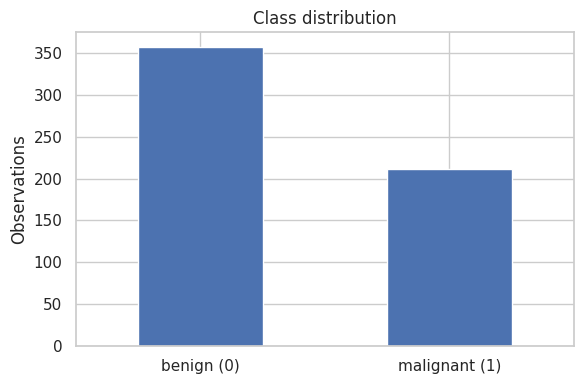

Strongest feature correlations:


,,correlation
mean radius,mean perimeter,0.997855
worst radius,worst perimeter,0.993708
mean radius,mean area,0.987357
mean perimeter,mean area,0.986507
worst radius,worst area,0.984015
worst perimeter,worst area,0.977578
radius error,perimeter error,0.972794
mean perimeter,worst perimeter,0.970387
mean radius,worst radius,0.969539
mean perimeter,worst radius,0.969476


In [21]:
cancer=load_breast_cancer(as_frame=True); raw=cancer.frame.copy()
X_cls=raw.drop(columns='target'); y_cls=(raw['target']==0).astype(int).rename('malignant')
cls_df=X_cls.copy(); cls_df['malignant']=y_cls

display(cls_df.head(10)); print('Rows, columns:',cls_df.shape); print('Features:',X_cls.shape[1]); print('Target: malignant (1=yes, 0=benign)')

print('Class names: benign (0), malignant (1)'); print('Missing:',int(cls_df.isna().sum().sum()))

display(X_cls.describe().T)

counts=y_cls.value_counts().sort_index(); dist=pd.DataFrame({'count':counts.values,'percent':counts.values/len(y_cls)*100},index=['benign (0)','malignant (1)']); display(dist)
dist['count'].plot.bar(figsize=(6,4),rot=0,title='Class distribution'); plt.ylabel('Observations'); savefig('classification_class_distribution.png')
top_pairs=X_cls.corr().where(np.triu(np.ones((X_cls.shape[1],X_cls.shape[1])),1).astype(bool)).stack().sort_values(key=abs,ascending=False)
print('Strongest feature correlations:'); display(top_pairs.head(10).to_frame('correlation'))

### B1 answers

1. This is binary classification: malignant or benign.
2. It is not perfectly balanced.
3. Benign is more common, as the generated class table shows.
4. With imbalance, a model can achieve high accuracy merely by favoring the majority class while failing to detect the clinically important minority class.
5. A false negative—predicting benign when a tumor is actually malignant—is generally more harmful because it can delay diagnosis and treatment. False positives also matter because they cause anxiety and additional testing.

In [22]:
Xc_train,Xc_test,yc_train,yc_test=train_test_split(X_cls,y_cls,test_size=.2,random_state=SEED,stratify=y_cls)
split_dist=pd.DataFrame({'Complete':y_cls.value_counts(normalize=True),'Train':yc_train.value_counts(normalize=True),'Test':yc_test.value_counts(normalize=True)}).sort_index()
split_dist.index=['benign (0)','malignant (1)']; display((split_dist*100).round(2).astype(str)+'%')
print('Shapes:',Xc_train.shape,Xc_test.shape,yc_train.shape,yc_test.shape)

,Complete,Train,Test
benign (0),62.74%,62.64%,63.16%
malignant (1),37.26%,37.36%,36.84%


Shapes: (455, 30) (114, 30) (455,) (114,)


### B2 answers

1. `stratify=y` makes the split preserve approximately the same class proportions as the complete dataset.
2. Stratification gives both train and test sets representative class mixtures and makes evaluation more stable.
3. If malignant cases were underrepresented in the test set, recall and other metrics could be unstable or misleading; in an extreme case, a metric could be undefined.

In [23]:
cls_models={
 'Baseline':DummyClassifier(strategy='most_frequent'),
 'Logistic Regression':Pipeline([('scaler',StandardScaler()),('model',LogisticRegression(max_iter=2000,random_state=SEED))]),
 'Decision Tree':Pipeline([('model',DecisionTreeClassifier(max_depth=5,random_state=SEED))]),
 'Random Forest':Pipeline([('model',RandomForestClassifier(n_estimators=200,random_state=SEED,n_jobs=-1))]),
 'SVM':Pipeline([('scaler',StandardScaler()),('model',SVC(probability=True,random_state=SEED))]),
 'Neural Network':Pipeline([('scaler',StandardScaler()),('model',MLPClassifier(hidden_layer_sizes=(64,32),max_iter=2000,early_stopping=True,random_state=SEED))])}

cls_cv_rows=[]; cls_rows=[]; fitted_cls={}; skfold=StratifiedKFold(5,shuffle=True,random_state=SEED)
cls_scoring={'Accuracy':'accuracy','Precision':'precision','Recall':'recall','F1':'f1','ROC_AUC':'roc_auc'}
for name,model in cls_models.items():
    if name!='Baseline':
        cvres=cross_validate(model,Xc_train,yc_train,cv=skfold,scoring=cls_scoring,n_jobs=-1)
        row={'Model':name}
        for k in cls_scoring: row[k+'_mean']=cvres['test_'+k].mean(); row[k+'_sd']=cvres['test_'+k].std()
        cls_cv_rows.append(row)
    fit=clone(model).fit(Xc_train,yc_train); fitted_cls[name]=fit
    tr_pred=fit.predict(Xc_train); te_pred=fit.predict(Xc_test); te_score=model_scores(fit,Xc_test)
    row={'Model':name,'Train_Accuracy':accuracy_score(yc_train,tr_pred),**classification_metrics(yc_test,te_pred,te_score)}
    cls_rows.append(row)
cls_cv=pd.DataFrame(cls_cv_rows).set_index('Model'); cls_results=pd.DataFrame(cls_rows).set_index('Model')
cls_cv.to_csv('results/classification_cross_validation.csv'); cls_results.to_csv('results/classification_results.csv')
display(cls_cv.round(3)); display(cls_results.round(3))

,Accuracy_mean,Accuracy_sd,Precision_mean,Precision_sd,Recall_mean,Recall_sd,F1_mean,F1_sd,ROC_AUC_mean,ROC_AUC_sd
Model,,,,,,,,,,
Logistic Regression,0.974,0.015,0.977,0.028,0.953,0.040,0.964,0.021,0.996,0.005
Decision Tree,0.908,0.040,0.894,0.037,0.853,0.085,0.872,0.057,0.887,0.061
Random Forest,0.963,0.015,0.964,0.011,0.935,0.039,0.949,0.021,0.989,0.007
SVM,0.971,0.005,0.977,0.021,0.947,0.034,0.961,0.008,0.995,0.005
Neural Network,0.884,0.061,0.943,0.047,0.729,0.147,0.816,0.110,0.962,0.027


,Train_Accuracy,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC
Model,,,,,,,
Baseline,0.626,0.632,0.000,0.000,1.000,0.000,0.500
Logistic Regression,0.987,0.965,0.975,0.929,0.986,0.951,0.996
Decision Tree,0.987,0.921,0.946,0.833,0.972,0.886,0.945
Random Forest,1.000,0.965,1.000,0.905,1.000,0.950,0.994
SVM,0.987,0.974,1.000,0.929,1.000,0.963,0.995
Neural Network,0.886,0.860,0.964,0.643,0.986,0.771,0.978


### B3–B5 answers

The baseline always predicts the training set’s most frequent class (benign). Its accuracy may appear respectable because benign is the majority, but its malignant precision, recall, and F1 reveal that it detects no malignant cases. Accuracy alone therefore conceals the clinically crucial failure.

The five required classifiers were trained. Logistic Regression, SVM, and Neural Network use pipelines with scaling; tree splits depend on ordering and thresholds, so Decision Tree and Random Forest do not need scaling. Stratified five-fold results are reported as separate means and standard deviations above.

Best testing-F1 model: SVM


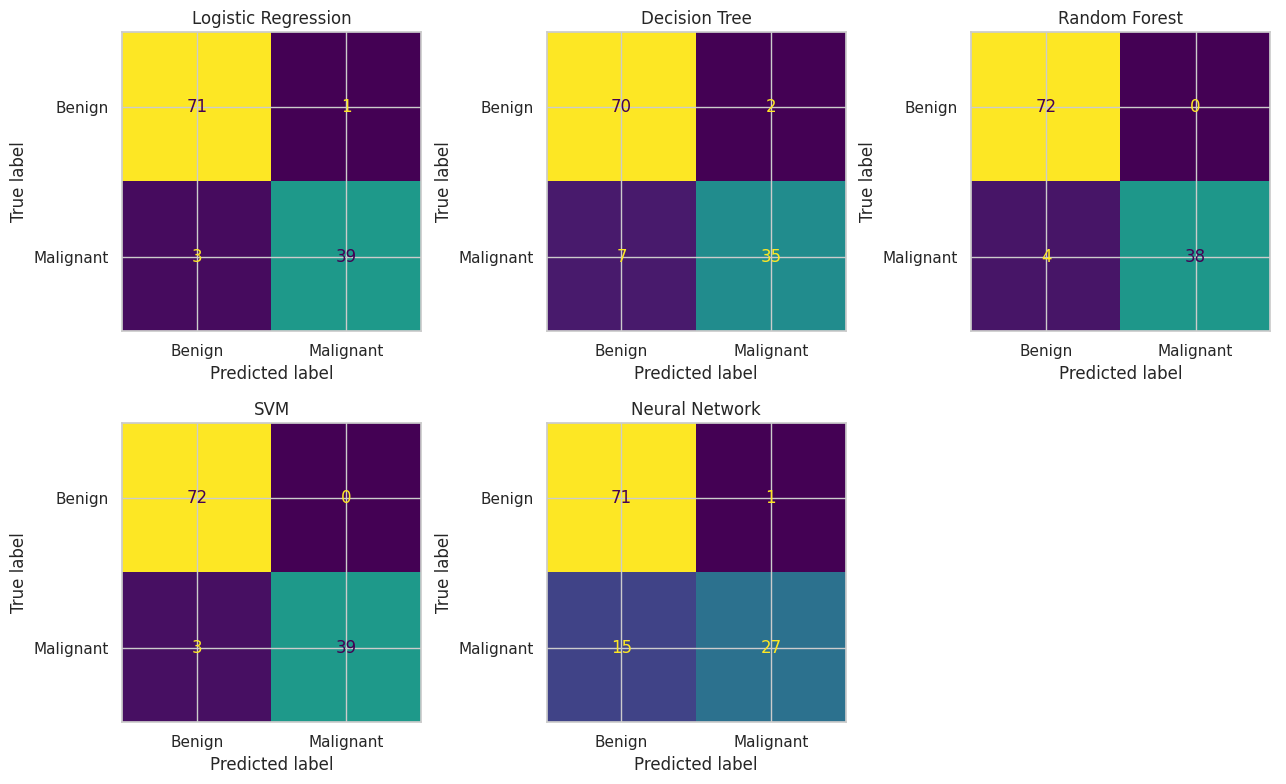

,SVM
TN,72.000000
FP,0.000000
FN,3.000000
TP,39.000000
Correct,111.000000
Incorrect,3.000000
Accuracy,0.973684
Precision,1.000000
Recall,0.928571
Specificity,1.000000



 Logistic Regression
              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        72
   malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


 Decision Tree
              precision    recall  f1-score   support

      benign       0.91      0.97      0.94        72
   malignant       0.95      0.83      0.89        42

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114


 Random Forest
              precision    recall  f1-score   support

      benign       0.95      1.00      0.97        72
   malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0

In [24]:
best_cls_name=cls_results.drop(index='Baseline')['F1'].idxmax(); best_cls=fitted_cls[best_cls_name]
print('Best testing-F1 model:',best_cls_name)
cms={}
fig,axes=plt.subplots(2,3,figsize=(13,8)); axes=axes.ravel()
for ax,(name,fit) in zip(axes,[(n,f) for n,f in fitted_cls.items() if n!='Baseline']):
    pred=fit.predict(Xc_test); cm=confusion_matrix(yc_test,pred,labels=[0,1]); cms[name]=cm
    ConfusionMatrixDisplay(cm,display_labels=['Benign','Malignant']).plot(ax=ax,colorbar=False); ax.set_title(name)
axes[-1].axis('off'); savefig('confusion_matrices/all_classification_models.png')

cm=cms[best_cls_name]; tn,fp,fn,tp=cm.ravel(); total=cm.sum()
manual=pd.Series({'TN':tn,'FP':fp,'FN':fn,'TP':tp,'Correct':tn+tp,'Incorrect':fp+fn,
 'Accuracy':(tp+tn)/total,'Precision':tp/(tp+fp),'Recall':tp/(tp+fn),
 'Specificity':tn/(tn+fp),'F1':2*(tp/(tp+fp))*(tp/(tp+fn))/((tp/(tp+fp))+(tp/(tp+fn)))})
display(manual.to_frame(best_cls_name))

for name,fit in fitted_cls.items():
    if name!='Baseline':
        print('\n',name); print(classification_report(yc_test,fit.predict(Xc_test),target_names=['benign','malignant'],zero_division=0))

### B6 answers
1. Correct predictions: There were 111 correct predictions.

2. Incorrect predictions: There were 3 incorrect predictions.

3. False positives: There were 0 false positives.

4. False negatives: There were 3 false negatives.

5. Which error is potentially more harmful? A false negative (predicting benign when a tumor is actually malignant) is generally more harmful, as it can delay diagnosis and treatment. In this specific case, 3 false negatives occurred.

6. Does the default target encoding match your chosen positive class? No, the original dataset encodes malignant as 0 and benign as 1. However, this notebook deliberately remapped malignant to 1 before splitting or modeling, so that the chosen positive class (malignant) aligns with the metrics.


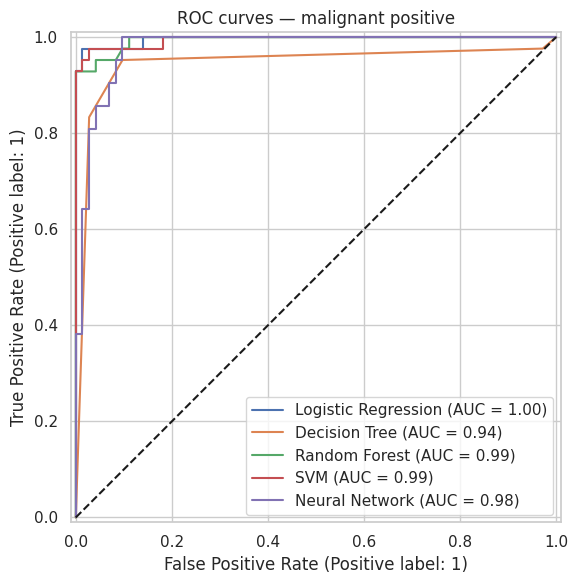

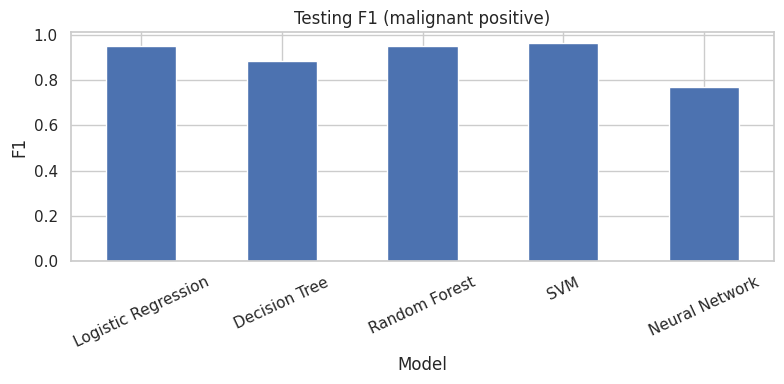

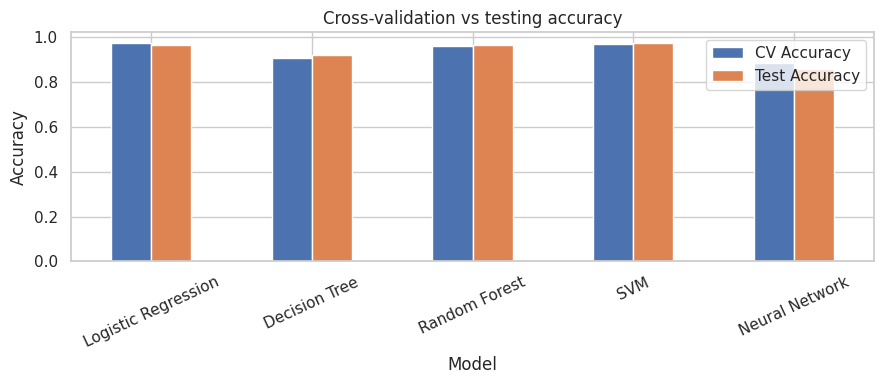

In [25]:
plt.figure(figsize=(7,6)); ax=plt.gca()
for name,fit in fitted_cls.items():
    if name!='Baseline': RocCurveDisplay.from_predictions(yc_test,model_scores(fit,Xc_test),name=name,ax=ax)
plt.plot([0,1],[0,1],'k--'); plt.title('ROC curves — malignant positive'); savefig('roc_curves.png')

cls_results.drop(index='Baseline')['F1'].plot.bar(figsize=(8,4),rot=25,title='Testing F1 (malignant positive)'); plt.ylabel('F1'); savefig('classification_f1_comparison.png')
compare=pd.DataFrame({'CV Accuracy':cls_cv['Accuracy_mean'],'Test Accuracy':cls_results.loc[cls_cv.index,'Accuracy']})
compare.plot.bar(figsize=(9,4),rot=25,title='Cross-validation vs testing accuracy'); plt.ylabel('Accuracy'); savefig('classification_cv_vs_test_accuracy.png')

# Part C — Hyperparameter Tuning

Three classification models are tuned: Random Forest (tree-based), SVM (support-vector), and Logistic Regression (linear). Selection uses malignant-class F1 on stratified cross-validation using **training data only**. The test set is consulted only after each search selects its best estimator. The evaluated parameter combinations are preserved in `results/tuning_all_combinations.csv`.

In [26]:
tune_specs={
 'Random Forest':(Pipeline([('model',RandomForestClassifier(random_state=SEED,n_jobs=-1))]),
                  {'model__n_estimators':[100,200],'model__max_depth':[None,5,10],'model__min_samples_split':[2,5]}),
 'SVM':(Pipeline([('scaler',StandardScaler()),('model',SVC(probability=True,random_state=SEED))]),
        {'model__C':[.1,1,10,100],'model__kernel':['linear','rbf'],'model__gamma':['scale',.01]}),
 'Logistic Regression':(Pipeline([('scaler',StandardScaler()),('model',LogisticRegression(max_iter=2000,random_state=SEED))]),
        {'model__C':[.01,.1,1,10,100]})}
tune_summary=[]; all_search=[]; tuned_models={}
for name,(pipe,grid) in tune_specs.items():
    search=GridSearchCV(pipe,grid,scoring='f1',cv=skfold,n_jobs=-1,return_train_score=True).fit(Xc_train,yc_train)
    tuned_models[name]=search.best_estimator_
    before=fitted_cls[name]; after=search.best_estimator_
    btr=f1_score(yc_train,before.predict(Xc_train)); bte=f1_score(yc_test,before.predict(Xc_test))
    atr=f1_score(yc_train,after.predict(Xc_train)); ate=f1_score(yc_test,after.predict(Xc_test))
    tune_summary.append({'Model':name,'Combinations':len(search.cv_results_['params']),'Best_parameters':str(search.best_params_),
                         'Best_CV_F1':search.best_score_,'Test_F1_before':bte,'Test_F1_after':ate,
                         'Train_F1_change':atr-btr,'Test_F1_change':ate-bte})
    tmp=pd.DataFrame(search.cv_results_); tmp.insert(0,'Model',name); all_search.append(tmp)
tuning_results=pd.DataFrame(tune_summary).set_index('Model'); tuning_results.to_csv('results/tuning_results.csv')
pd.concat(all_search).to_csv('results/tuning_all_combinations.csv',index=False)
display(tuning_results)
print('Generalization interpretation: positive test-F1 change indicates improved held-out performance; a training-only increase without a test increase suggests extra fit rather than better generalization.')

,Combinations,Best_parameters,Best_CV_F1,Test_F1_before,Test_F1_after,Train_F1_change,Test_F1_change
Model,,,,,,,
Random Forest,12,"{'model__max_depth': 5, 'model__min_samples_sp...",0.955285,0.950000,0.962963,-0.008902,0.012963
SVM,16,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",0.967410,0.962963,0.962963,0.003039,0.000000
Logistic Regression,5,{'model__C': 1},0.964048,0.951220,0.951220,0.000000,0.000000


Generalization interpretation: positive test-F1 change indicates improved held-out performance; a training-only increase without a test increase suggests extra fit rather than better generalization.


# Part D — Model Interpretation

,standardized_coefficient
s1,-44.448856
sex,-11.511809
age,1.753758
s6,2.351364
s3,7.676978
s4,13.138784
bp,16.828872
s2,24.640954
bmi,25.607121
s5,35.161195


Three largest positive:


,0
s5,35.161195
bmi,25.607121
s2,24.640954


Three largest negative:


,0
s1,-44.448856
sex,-11.511809
age,1.753758


,importance
bmi,0.353246
s5,0.236397
bp,0.088485
s6,0.068979
s2,0.059566
age,0.057964
s1,0.052122
s3,0.050881
s4,0.023055
sex,0.009305


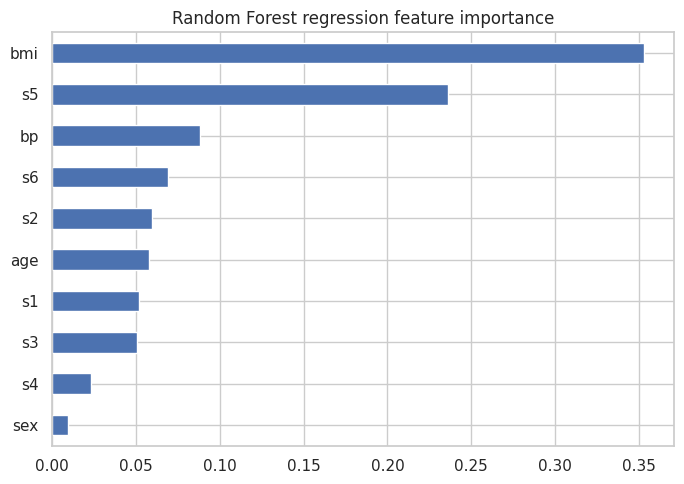

,coefficient_for_malignant
compactness error,-0.906925
fractal dimension error,-0.593876
mean compactness,-0.439546
texture error,-0.407611
symmetry error,-0.330658
worst compactness,-0.173488
mean symmetry,-0.163991
concavity error,-0.092341
mean fractal dimension,-0.080865
worst fractal dimension,0.054870


Largest positive (greater estimated malignant probability):


,0
worst texture,1.434093
radius error,1.233325
worst symmetry,1.061264
mean concave points,0.952813
worst concavity,0.911406
area error,0.909029
worst area,0.900477
worst radius,0.896968
mean concavity,0.782298
perimeter error,0.748295


Largest negative (greater estimated benign probability):


,0
compactness error,-0.906925
fractal dimension error,-0.593876
mean compactness,-0.439546
texture error,-0.407611
symmetry error,-0.330658
worst compactness,-0.173488
mean symmetry,-0.163991
concavity error,-0.092341
mean fractal dimension,-0.080865
worst fractal dimension,0.054870


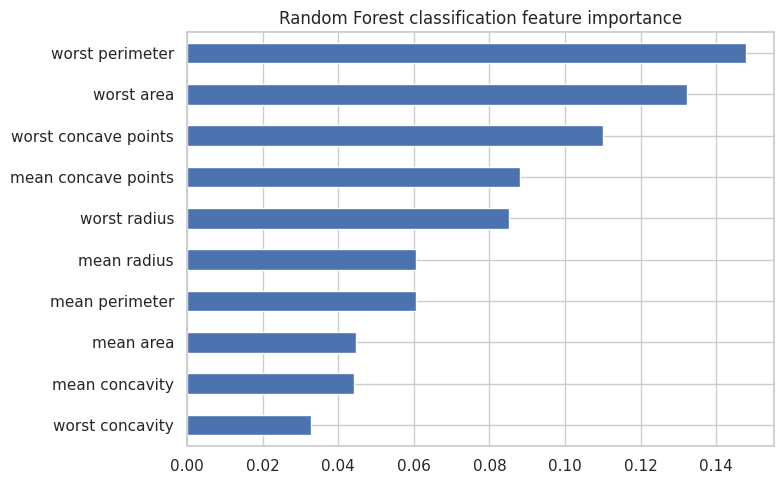

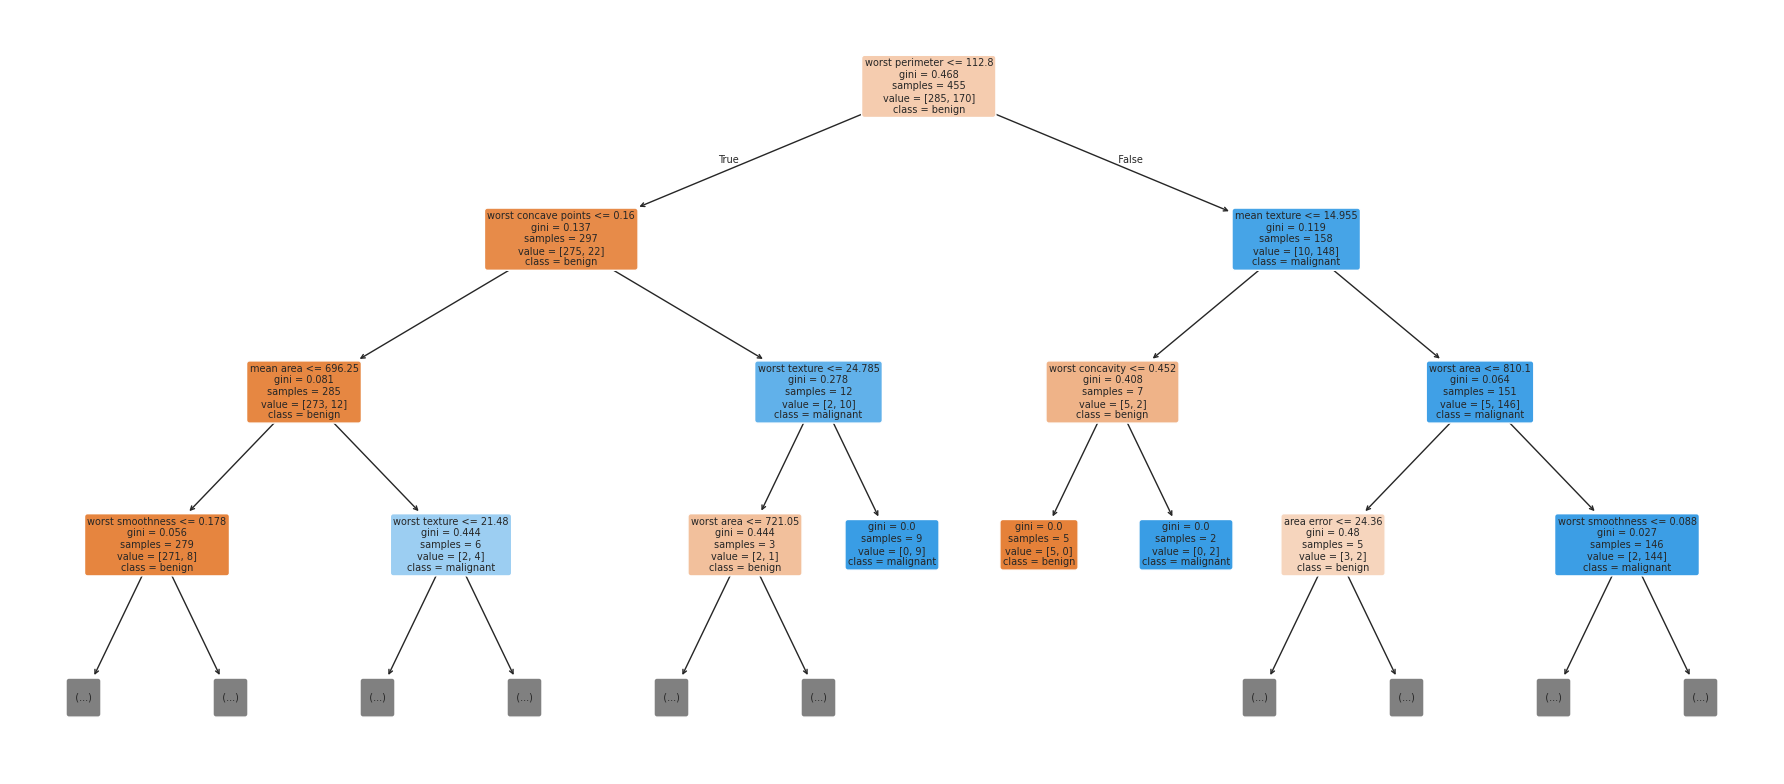

Example complete root-to-leaf path (always taking the left branch):
worst perimeter <= 112.800 AND worst concave points <= 0.160 AND mean area <= 696.250 AND worst smoothness <= 0.178 AND worst perimeter <= 102.400 => leaf predicts benign with class counts [0.99190283 0.00809717]


In [27]:
# Regression coefficients (the pipeline standardized inputs, making magnitudes more comparable)
lin=fitted_reg['Linear Regression']; lin_coef=pd.Series(lin.named_steps['model'].coef_,index=X_reg.columns).sort_values()
display(lin_coef.to_frame('standardized_coefficient'))
print('Three largest positive:'); display(lin_coef.nlargest(3)); print('Three largest negative:'); display(lin_coef.nsmallest(3))

rf_reg=fitted_reg['Random Forest'].named_steps['model']; rf_reg_imp=pd.Series(rf_reg.feature_importances_,index=X_reg.columns).sort_values(ascending=False)
display(rf_reg_imp.to_frame('importance')); rf_reg_imp.head(10).sort_values().plot.barh(figsize=(7,5),title='Random Forest regression feature importance'); savefig('rf_regression_feature_importance.png')

log=fitted_cls['Logistic Regression']; log_coef=pd.Series(log.named_steps['model'].coef_[0],index=X_cls.columns).sort_values()
display(log_coef.to_frame('coefficient_for_malignant'))
print('Largest positive (greater estimated malignant probability):'); display(log_coef.nlargest(10))
print('Largest negative (greater estimated benign probability):'); display(log_coef.nsmallest(10))

rf_cls=fitted_cls['Random Forest'].named_steps['model']; rf_cls_imp=pd.Series(rf_cls.feature_importances_,index=X_cls.columns).sort_values(ascending=False)
rf_cls_imp.head(10).sort_values().plot.barh(figsize=(8,5),title='Random Forest classification feature importance'); savefig('rf_classification_feature_importance.png')

tree=fitted_cls['Decision Tree'].named_steps['model']; plt.figure(figsize=(18,8)); plot_tree(tree,max_depth=3,feature_names=X_cls.columns,class_names=['benign','malignant'],filled=True,rounded=True,fontsize=7); savefig('decision_tree_first_three_levels.png')

node=0; path=[]
while tree.tree_.children_left[node]!=tree.tree_.children_right[node]:
    feat=X_cls.columns[tree.tree_.feature[node]]; threshold=tree.tree_.threshold[node]
    node=tree.tree_.children_left[node]; path.append(f'{feat} <= {threshold:.3f}')
leaf_counts=tree.tree_.value[node][0]; leaf_class=['benign','malignant'][np.argmax(leaf_counts)]
print('Example complete root-to-leaf path (always taking the left branch):')
print(' AND '.join(path),'=> leaf predicts',leaf_class,'with class counts',leaf_counts)

### Part D answers

- A positive Linear Regression coefficient means a higher standardized feature value is associated with a higher predicted progression score while holding other features fixed; a negative coefficient means the reverse. Correlated predictors can make individual coefficients unstable.
- A positive Logistic Regression coefficient increases estimated log-odds of **malignancy**; a negative coefficient points toward benign. Because inputs were standardized, the coefficient magnitudes are more comparable, but correlation still complicates attribution.


1. Do Linear or Logistic Regression and Random Forest identify similar important features? The tables allow for direct comparison between linear/logistic regression and Random Forest. While these models may overlap on broad signals, their feature importance rankings need not perfectly match. This is because Random Forests can capture nonlinearities and interactions between features, whereas linear models primarily estimate conditional linear effects.

2. Are feature-importance values equivalent to causal importance? No, feature importance values are not equivalent to causal importance. Feature importance measures how predictively useful a feature is within the context of the given dataset and the fitted model. It does not provide evidence of a causal relationship or the effect of intervening on a feature.

3. Which model is easiest to explain? A shallow Decision Tree is generally the easiest to explain, as it provides explicit 'if/then' rules. Linear and Logistic Regression models are also globally transparent, though their coefficients require careful interpretation, especially when scaling is involved.

4. What is the tradeoff between interpretability and predictive performance? There is often a tradeoff. Simpler models tend to be easier to explain but may have lower predictive performance. More flexible ensembles or nonlinear models can achieve better predictions but are typically harder to interpret. In applications like medicine, the need for transparency and understanding the costs of different errors should be weighed alongside predictive performance.


# Part E — Required Conceptual Analysis

1. **Regression vs classification:** Regression predicts a continuous quantity, such as disease progression. Classification predicts a discrete label, such as malignant or benign.
2. **Linear vs Logistic Regression:** Linear Regression estimates a continuous outcome with a linear combination of inputs. Logistic Regression models class log-odds and transforms them into a probability used for classification.
3. **Why scale SVMs and neural networks:** Their optimization and distance/margin computations are sensitive to numerical magnitude. Without scaling, large-unit features can dominate and optimization may converge poorly.
4. **Why trees usually do not need scaling:** A tree compares one feature at a time with thresholds. A monotonic rescaling preserves ordering and therefore does not materially change possible splits.
5. **Train, validation, test:** Training data fit parameters; validation data or cross-validation choose models/hyperparameters; testing data provide one final unbiased generalization estimate.
6. **Data leakage:** Leakage occurs when training uses information unavailable at prediction time or information from validation/test examples. Fitting `StandardScaler` on the complete dataset before splitting would leak test-set means and standard deviations. Pipelines prevent that here.
7. **K-fold cross-validation:** Split training data into k folds, train k times on k−1 folds, validate on the remaining fold, then summarize the k scores.
8. **Why CV only on training data:** If the test set participates in selection, its information influences the final model and it can no longer provide an independent final estimate.
9. **RMSE:** The square root of mean squared residuals; it estimates typical prediction error in target units while emphasizing large misses.
10. **RMSE vs MAE and outliers:** Squaring makes a residual twice as large contribute four times as much, whereas MAE grows linearly.
11. **R²:** The fraction of target variance explained relative to predicting the target mean. 1 is perfect, 0 matches the mean baseline, and negative is worse than that baseline.
12. **Confusion matrix:** Counts true negatives, false positives, false negatives, and true positives, revealing both the amount and direction of classification errors.
13. **Precision vs recall:** Precision asks, “Of predicted malignant cases, how many were malignant?” Recall asks, “Of all malignant cases, how many did we detect?”
14. **Medical false negatives:** They can falsely reassure a patient and delay follow-up or treatment for a real disease.
15. **Misleading accuracy:** A model can predict the majority class almost always, obtain high accuracy, and still fail on the minority class.
16. **Overfitting:** Learning noise or training-specific detail so well that training performance is high but performance on unseen data deteriorates.
17. **Detecting overfitting:** A much better training score than testing or cross-validation score is a generalization gap and evidence of overfitting.
18. **Why unrestricted trees overfit:** They can keep splitting until leaves represent very small groups or individual observations, encoding noise.
19. **How Random Forest helps:** It averages many decorrelated trees trained on bootstrap samples and random feature subsets, reducing variance and sensitivity to any single sample.
20. **Best overall model:** There is no single model across two different prediction tasks. For regression, the selected model is the one with the lowest held-out RMSE, supported by its test R² and cross-validation stability. For classification, the selected model is the one with the highest malignant-class test F1, checked against recall, ROC-AUC, confusion matrix, and cross-validation. The exact names and evidence are generated in the summary cell below.

In [28]:
final_summary=pd.DataFrame([
 {'Task':'Regression','Selected_model':best_reg_name,'Primary_metric':'Test RMSE','Value':reg_results.loc[best_reg_name,'Test_RMSE'],'Supporting_metric':f"Test R2={reg_results.loc[best_reg_name,'Test_R2']:.3f}"},
 {'Task':'Classification','Selected_model':best_cls_name,'Primary_metric':'Test F1 (malignant)','Value':cls_results.loc[best_cls_name,'F1'],'Supporting_metric':f"Recall={cls_results.loc[best_cls_name,'Recall']:.3f}, ROC-AUC={cls_results.loc[best_cls_name,'ROC_AUC']:.3f}"}])
final_summary.to_csv('results/final_model_summary.csv',index=False); display(final_summary)
print('Notebook complete. Tables are in results/ and figures are in figures/.')

,Task,Selected_model,Primary_metric,Value,Supporting_metric
0,Regression,Linear Regression,Test RMSE,53.853446,Test R2=0.453
1,Classification,SVM,Test F1 (malignant),0.962963,"Recall=0.929, ROC-AUC=0.995"


Notebook complete. Tables are in results/ and figures are in figures/.
